# SIMULASI PROYEK PEMBANGUNAN GEDUNG FITE 5 LANTAI
## Analisis Durasi, Risiko, dan Optimasi Resource Menggunakan Monte Carlo

**Tujuan:**
1. Memperkirakan durasi total proyek pembangunan
2. Menganalisis risiko keterlambatan akibat faktor ketidakpastian
3. Identifikasi tahapan kritis (critical path)
4. Menghitung probabilitas penyelesaian pada berbagai deadline
5. Mengevaluasi dampak penambahan resource terhadap akselerasi proyek

**Fasilitas Gedung:**
- 5 Lantai
- Ruang Kelas
- Laboratorium Komputer
- Laboratorium Elektro
- Laboratorium Mobile
- Laboratorium VR/AR
- Laboratorium Game
- Ruang Dosen
- Toilet
- Ruang Serbaguna

In [43]:
# ============================================================================
# 1. KONFIGURASI
# ============================================================================

# IMPOR LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Konfigurasi
NUM_SIMULATIONS = 20000  # Lebih banyak iterasi untuk hasil yang lebih akurat
np.random.seed(42)

print("✓ Library berhasil dimuat")
print(f"✓ Jumlah simulasi: {NUM_SIMULATIONS:,}")

✓ Library berhasil dimuat
✓ Jumlah simulasi: 20,000


In [44]:
# ============================================================================
# 2. PEMODELAN SISTEM
# ============================================================================

class ProjectStage:
    """Kelas untuk memodelkan tahapan proyek dengan kompleksitas realistis"""
    
    def __init__(self, name, base_params, risk_factors=None, dependencies=None):
        """
        Parameters:
        -----------
        name : str
            Nama tahapan
        base_params : dict
            Parameter dasar durasi dalam bulan (optimistic, most_likely, pessimistic)
        risk_factors : dict
            Faktor risiko yang mempengaruhi durasi
        dependencies : list
            Dependensi dengan tahapan lain
        """
        self.name = name
        self.optimistic = base_params['optimistic']
        self.most_likely = base_params['most_likely']
        self.pessimistic = base_params['pessimistic']
        self.risk_factors = risk_factors or {}
        self.dependencies = dependencies or []
        
    def sample_duration(self, n_simulations, risk_multiplier=1.0):
        """
        Sampling durasi dengan mempertimbangkan distribusi dan faktor risiko
        Distribusi triangular (Three-Point Estimation)
        """
        # Distribusi triangular untuk estimasi tiga titik
        base_duration = np.random.triangular(
            self.optimistic,
            self.most_likely,
            self.pessimistic,
            n_simulations
        )
        
        # Aplikasi faktor risiko
        total_risk_effect = 1.0
        
        for risk_name, risk_params in self.risk_factors.items():
            if risk_params['type'] == 'discrete':
                # Risiko diskrit (misal: cuaca buruk, keterlambatan material)
                probability = risk_params['probability']
                impact = risk_params['impact']
                
                # Generate kejadian risiko
                risk_occurs = np.random.random(n_simulations) < probability
                
                # Aplikasi impact jika risiko terjadi
                base_duration = np.where(
                    risk_occurs,
                    base_duration * (1 + impact),
                    base_duration
                )
                
            elif risk_params['type'] == 'continuous':
                # Risiko kontinu (misal: produktivitas pekerja)
                mean = risk_params['mean']
                std = risk_params['std']
                
                # Sampling dari distribusi normal
                productivity_factor = np.random.normal(mean, std, n_simulations)
                base_duration = base_duration / np.clip(productivity_factor, 0.5, 1.5)
        
        return base_duration * risk_multiplier

In [45]:
# ============================================================================
# 3. DEFINISI TAHAPAN PROYEK PEMBANGUNAN GEDUNG FITE
# ============================================================================

# Durasi dalam BULAN (karena total proyek 16-24 bulan)
# Estimasi: Optimistic, Most Likely, Pessimistic

project_stages_config = {
    "1_Persiapan_Lahan_dan_Fondasi": {
        "base_params": {"optimistic": 1.5, "most_likely": 2.5, "pessimistic": 4},
        "risk_factors": {
            "cuaca_buruk": {
                "type": "discrete",
                "probability": 0.35,  # 35% kemungkinan cuaca mengganggu
                "impact": 0.4  # +40% durasi jika terjadi
            },
            "kondisi_tanah_sulit": {
                "type": "discrete",
                "probability": 0.2,
                "impact": 0.5
            },
            "produktivitas_kerja": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.15
            }
        }
    },
    "2_Struktur_Beton_5_Lantai": {
        "base_params": {"optimistic": 4, "most_likely": 6, "pessimistic": 9},
        "risk_factors": {
            "keterlambatan_material_beton": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.35
            },
            "cuaca_ekstrem": {
                "type": "discrete",
                "probability": 0.25,
                "impact": 0.3
            },
            "kesalahan_struktur_minor": {
                "type": "discrete",
                "probability": 0.15,
                "impact": 0.2
            },
            "efisiensi_kerja_tim": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.2
            }
        },
        "dependencies": ["1_Persiapan_Lahan_dan_Fondasi"]
    },
    "3_Selubung_Bangunan_dan_Atap": {
        "base_params": {"optimistic": 1.5, "most_likely": 2.5, "pessimistic": 4},
        "risk_factors": {
            "keterlambatan_material_atap": {
                "type": "discrete",
                "probability": 0.25,
                "impact": 0.3
            },
            "cuaca_tidak_kondusif": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.25
            }
        },
        "dependencies": ["2_Struktur_Beton_5_Lantai"]
    },
    "4_Sistem_MEP_Basic": {
        "base_params": {"optimistic": 2, "most_likely": 3.5, "pessimistic": 5.5},
        "risk_factors": {
            "keterlambatan_peralatan_teknis": {
                "type": "discrete",
                "probability": 0.4,  # Risiko tinggi untuk peralatan teknis
                "impact": 0.4
            },
            "ketersediaan_teknisi_ahli": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.25
            }
        },
        "dependencies": ["3_Selubung_Bangunan_dan_Atap"]
    },
    "5_Interior_dan_Finishing": {
        "base_params": {"optimistic": 2, "most_likely": 3, "pessimistic": 5},
        "risk_factors": {
            "perubahan_desain": {
                "type": "discrete",
                "probability": 0.35,
                "impact": 0.4  # Perubahan desain sangat mempengaruhi timeline
            },
            "keterlambatan_material_finishing": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.25
            }
        },
        "dependencies": ["4_Sistem_MEP_Basic"]
    },
    "6_Instalasi_Laboratorium_dan_Furnitur": {
        "base_params": {"optimistic": 2.5, "most_likely": 4, "pessimistic": 6.5},
        "risk_factors": {
            "keterlambatan_lab_equipment": {
                "type": "discrete",
                "probability": 0.45,  # Sangat sering terjadi untuk lab khusus
                "impact": 0.5
            },
            "kompleksitas_instalasi_lab": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.3  # Variabilitas tinggi
            },
            "perubahan_spesifikasi_lab": {
                "type": "discrete",
                "probability": 0.25,
                "impact": 0.3
            }
        },
        "dependencies": ["5_Interior_dan_Finishing"]
    },
    "7_Testing_dan_Commissioning": {
        "base_params": {"optimistic": 1, "most_likely": 1.5, "pessimistic": 3},
        "risk_factors": {
            "defect_ditemukan": {
                "type": "discrete",
                "probability": 0.4,
                "impact": 0.5  # Jika ada defect, durasi meningkat
            },
            "lab_equipment_malfunction": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.6
            }
        },
        "dependencies": ["6_Instalasi_Laboratorium_dan_Furnitur"]
    },
    "8_Final_Inspection_dan_Handover": {
        "base_params": {"optimistic": 0.5, "most_likely": 1, "pessimistic": 2},
        "risk_factors": {
            "perbaikan_catatan_defect": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.4
            }
        },
        "dependencies": ["7_Testing_dan_Commissioning"]
    }
}

print("✓ Konfigurasi tahapan proyek berhasil dibuat")
print(f"✓ Total tahapan: {len(project_stages_config)}")
for stage_name in project_stages_config.keys():
    print(f"  - {stage_name}")

✓ Konfigurasi tahapan proyek berhasil dibuat
✓ Total tahapan: 8
  - 1_Persiapan_Lahan_dan_Fondasi
  - 2_Struktur_Beton_5_Lantai
  - 3_Selubung_Bangunan_dan_Atap
  - 4_Sistem_MEP_Basic
  - 5_Interior_dan_Finishing
  - 6_Instalasi_Laboratorium_dan_Furnitur
  - 7_Testing_dan_Commissioning
  - 8_Final_Inspection_dan_Handover


In [46]:
# ============================================================================
# 4. SIMULATOR MONTE CARLO
# ============================================================================

class MonteCarloProjectSimulation:
    """Kelas untuk menjalankan simulasi Monte Carlo untuk proyek konstruksi"""
    
    def __init__(self, stages_config, num_simulations=10000):
        self.stages_config = stages_config
        self.num_simulations = num_simulations
        self.stages = {}
        self.simulation_results = None
        self.initialize_stages()
        
    def initialize_stages(self):
        """Inisialisasi objek tahapan dari konfigurasi"""
        for stage_name, config in self.stages_config.items():
            self.stages[stage_name] = ProjectStage(
                name=stage_name,
                base_params=config['base_params'],
                risk_factors=config.get('risk_factors', {}),
                dependencies=config.get('dependencies', [])
            )
    
    def run_simulation(self):
        """Menjalankan simulasi Monte Carlo lengkap dengan network analysis"""
        results = pd.DataFrame(index=range(self.num_simulations))
        
        # Simulasi durasi per tahapan
        for stage_name, stage in self.stages.items():
            results[stage_name] = stage.sample_duration(self.num_simulations)
        
        # Network analysis: hitung waktu mulai dan selesai berdasarkan dependensi
        start_times = pd.DataFrame(index=range(self.num_simulations))
        end_times = pd.DataFrame(index=range(self.num_simulations))
        
        # Order stages berdasarkan dependensi (topological sort)
        processed_stages = set()
        stage_order = []
        
        while len(processed_stages) < len(self.stages):
            for stage_name in self.stages.keys():
                if stage_name in processed_stages:
                    continue
                    
                deps = self.stages[stage_name].dependencies
                if all(dep in processed_stages for dep in deps):
                    stage_order.append(stage_name)
                    processed_stages.add(stage_name)
        
        # Hitung finish time untuk setiap tahapan
        for stage_name in stage_order:
            deps = self.stages[stage_name].dependencies
            
            if not deps:
                # Jika tidak ada dependensi, mulai dari bulan 0
                start_times[stage_name] = 0
            else:
                # Mulai setelah semua dependensi selesai (max dari semua dependencies)
                start_times[stage_name] = end_times[deps].max(axis=1)
            
            # Waktu selesai = waktu mulai + durasi
            end_times[stage_name] = start_times[stage_name] + results[stage_name]
        
        # Hitung durasi total proyek
        results['Total_Duration'] = end_times.max(axis=1)
        
        # Simpan waktu start dan finish per tahapan
        for stage_name in self.stages.keys():
            results[f'{stage_name}_Finish'] = end_times[stage_name]
            results[f'{stage_name}_Start'] = start_times[stage_name]
        
        self.simulation_results = results
        return results
    
    def calculate_critical_path_probability(self):
        """Menghitung probabilitas setiap tahapan berada di critical path"""
        if self.simulation_results is None:
            raise ValueError("Jalankan simulasi terlebih dahulu")
        
        critical_path_probs = {}
        total_duration = self.simulation_results['Total_Duration']
        
        for stage_name in self.stages.keys():
            # Tahapan di critical path jika slack-nya minimal (~0)
            stage_finish = self.simulation_results[f'{stage_name}_Finish']
            stage_duration = self.simulation_results[stage_name]
            
            # Slack = total_duration - stage_finish
            slack = total_duration - stage_finish
            
            # Tahapan di critical path jika slack mendekati 0 (< 0.5 bulan)
            is_critical = slack < 0.5
            prob_critical = np.mean(is_critical)
            
            # Hitung korelasi dengan total duration
            correlation = stage_duration.corr(total_duration)
            
            critical_path_probs[stage_name] = {
                'probability': prob_critical,
                'correlation': correlation,
                'avg_duration': stage_duration.mean(),
                'avg_slack': slack.mean()
            }
        
        return pd.DataFrame(critical_path_probs).T
    
    def analyze_risk_contribution(self):
        """Analisis kontribusi risiko terhadap variabilitas total durasi"""
        if self.simulation_results is None:
            raise ValueError("Jalankan simulasi terlebih dahulu")
        
        total_var = self.simulation_results['Total_Duration'].var()
        
        contributions = {}
        for stage_name in self.stages.keys():
            stage_var = self.simulation_results[stage_name].var()
            stage_covar = self.simulation_results[stage_name].cov(
                self.simulation_results['Total_Duration']
            )
            
            # Proporsi kontribusi terhadap varians total
            contribution = (stage_covar / total_var) * 100 if total_var > 0 else 0
            
            contributions[stage_name] = {
                'variance': stage_var,
                'contribution_percent': contribution,
                'std_dev': np.sqrt(stage_var),
                'cv': np.sqrt(stage_var) / self.simulation_results[stage_name].mean()  # Coefficient of variation
            }
        
        return pd.DataFrame(contributions).T

In [47]:
# ============================================================================
# 5. MENJALANKAN SIMULASI MONTE CARLO
# ============================================================================

print("\n" + "="*70)
print("MENJALANKAN SIMULASI MONTE CARLO")
print("="*70)

# Inisialisasi dan jalankan simulasi
simulator = MonteCarloProjectSimulation(
    stages_config=project_stages_config,
    num_simulations=NUM_SIMULATIONS
)

print(f"\nMenjalankan {NUM_SIMULATIONS:,} simulasi...")
results = simulator.run_simulation()

print(f"✓ Simulasi selesai")
print(f"\nDimensi hasil: {results.shape}")
print(f"\nSample hasil (5 baris pertama):")
print(results.head())


MENJALANKAN SIMULASI MONTE CARLO

Menjalankan 20,000 simulasi...
✓ Simulasi selesai

Dimensi hasil: (20000, 25)

Sample hasil (5 baris pertama):
   1_Persiapan_Lahan_dan_Fondasi  2_Struktur_Beton_5_Lantai  \
0                       2.282335                  11.178127   
1                       7.130236                   7.758331   
2                       8.649384                   8.192871   
3                       4.367459                   5.174333   
4                       1.808765                  13.469605   

   3_Selubung_Bangunan_dan_Atap  4_Sistem_MEP_Basic  5_Interior_dan_Finishing  \
0                      4.547022            7.193957                  5.109672   
1                      4.127103            3.408625                  4.019695   
2                      2.460618            7.018956                  4.937178   
3                      3.160224            3.072048                  4.563013   
4                      3.432245            3.432278                  2


MEMBUAT VISUALISASI


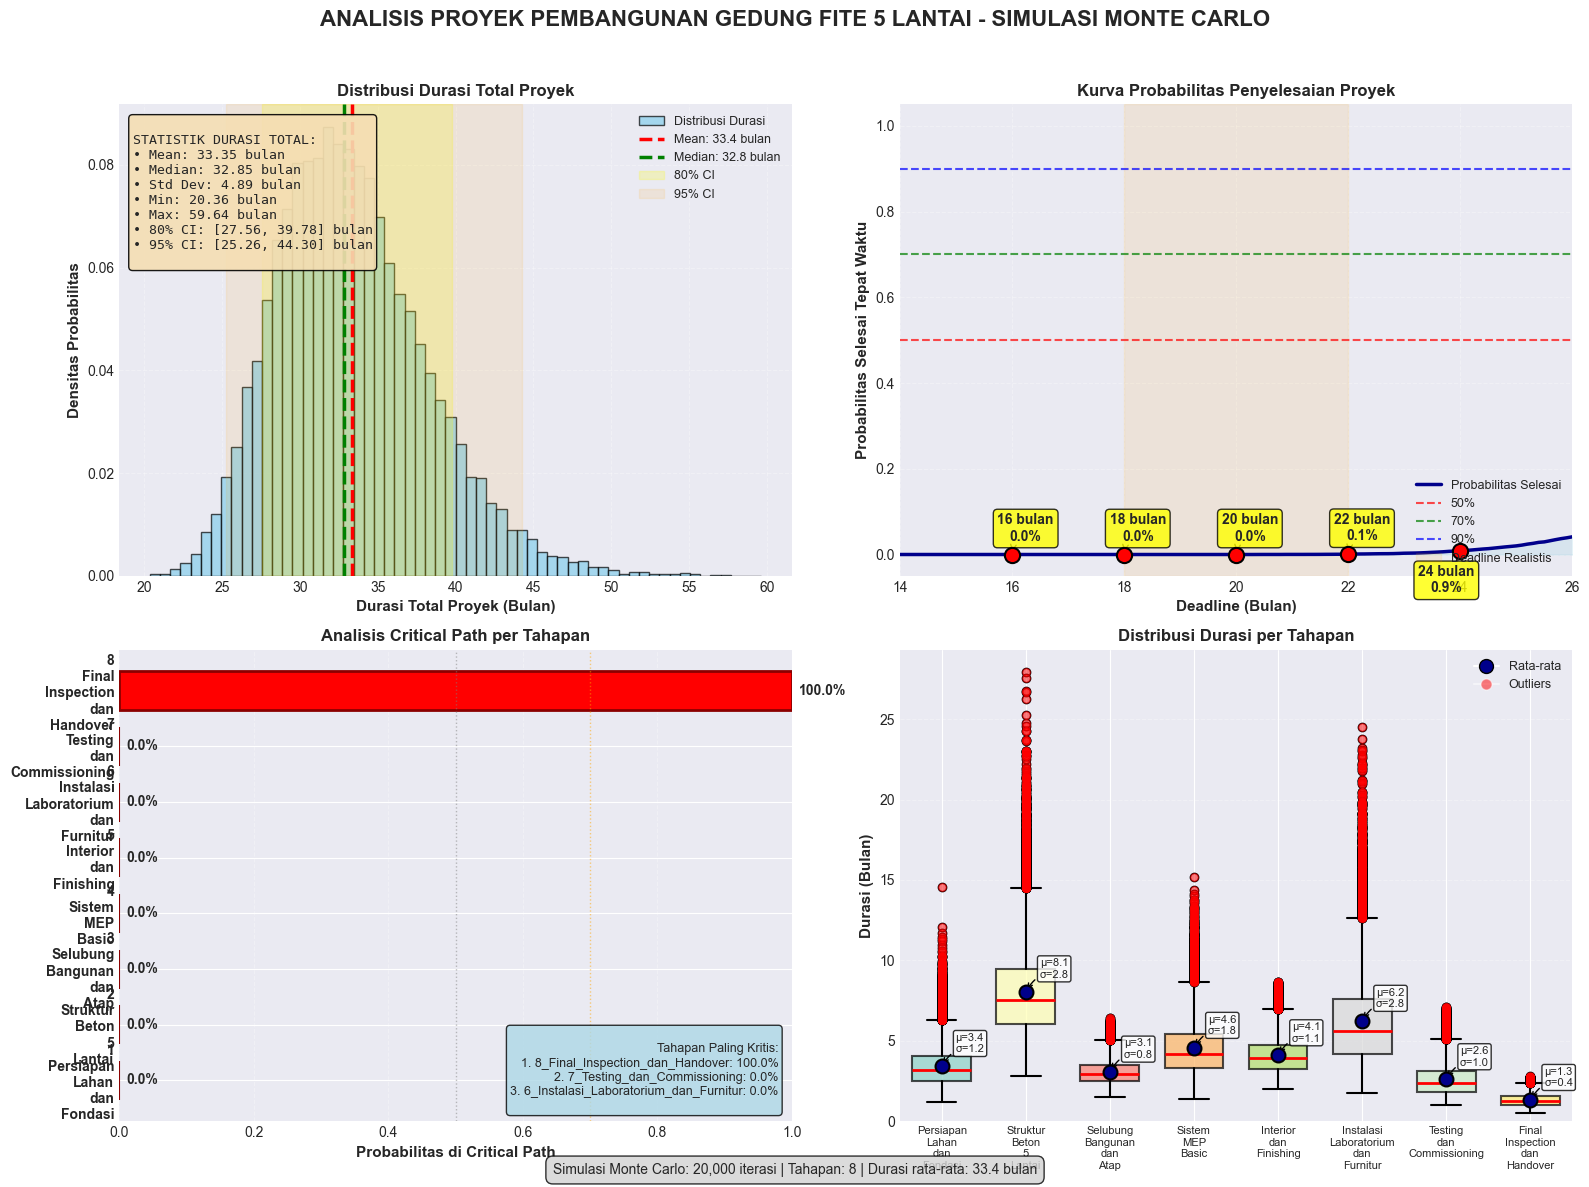

✓ Visualisasi 1 (Main Dashboard) berhasil dibuat


In [48]:
# ============================================================================
# 6. VISUALISASI KOMPREHENSIF
# ============================================================================

print("\n" + "="*70)
print("MEMBUAT VISUALISASI")
print("="*70)

# Setup figure untuk 2x2 plot (mengikuti style simulasi-app)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANALISIS PROYEK PEMBANGUNAN GEDUNG FITE 5 LANTAI - SIMULASI MONTE CARLO', 
             fontsize=16, fontweight='bold', y=0.98)

# PLOT 1: Distribusi Durasi Total Proyek (Kiri Atas)
ax1 = axes[0, 0]
ax1.hist(results['Total_Duration'], bins=60, edgecolor='black', alpha=0.7, 
         density=True, color='skyblue', label='Distribusi Durasi')

# Tambahkan garis mean, median, dan percentile
mean_duration = results['Total_Duration'].mean()
median_duration = np.median(results['Total_Duration'])
ax1.axvline(mean_duration, color='red', linestyle='--', linewidth=2.5, 
            label=f'Mean: {mean_duration:.1f} bulan')
ax1.axvline(median_duration, color='green', linestyle='--', linewidth=2.5, 
            label=f'Median: {median_duration:.1f} bulan')

# Confidence intervals
ci_80 = np.percentile(results['Total_Duration'], [10, 90])
ci_95 = np.percentile(results['Total_Duration'], [2.5, 97.5])

ax1.axvspan(ci_80[0], ci_80[1], alpha=0.2, color='yellow', label='80% CI')
ax1.axvspan(ci_95[0], ci_95[1], alpha=0.1, color='orange', label='95% CI')

# Statistik penting
stats_text = f"""
STATISTIK DURASI TOTAL:
• Mean: {mean_duration:.2f} bulan
• Median: {median_duration:.2f} bulan
• Std Dev: {results['Total_Duration'].std():.2f} bulan
• Min: {results['Total_Duration'].min():.2f} bulan
• Max: {results['Total_Duration'].max():.2f} bulan
• 80% CI: [{ci_80[0]:.2f}, {ci_80[1]:.2f}] bulan
• 95% CI: [{ci_95[0]:.2f}, {ci_95[1]:.2f}] bulan
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.02, 0.97, stats_text, transform=ax1.transAxes, fontsize=9.5,
         verticalalignment='top', bbox=props, fontfamily='monospace')

ax1.set_xlabel('Durasi Total Proyek (Bulan)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Densitas Probabilitas', fontsize=11, fontweight='bold')
ax1.set_title('Distribusi Durasi Total Proyek', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# PLOT 2: Kurva Probabilitas Deadline (Kanan Atas)
ax2 = axes[0, 1]

# Deadlines yang relevan untuk proyek (16-24 bulan)
deadlines = np.arange(14, 26.1, 0.1)
completion_probs = []

for deadline in deadlines:
    prob = np.mean(results['Total_Duration'] <= deadline)
    completion_probs.append(prob)

# Plot kurva probabilitas
ax2.plot(deadlines, completion_probs, linewidth=2.5, color='darkblue', 
         label='Probabilitas Selesai')
ax2.fill_between(deadlines, completion_probs, alpha=0.3, color='lightblue')

# Garis referensi probabilitas
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='50%')
ax2.axhline(0.7, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='70%')
ax2.axhline(0.9, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='90%')

# Tandai deadline penting dengan anotasi
key_deadlines = [16, 18, 20, 22, 24]
for dl in key_deadlines:
    idx = np.argmin(np.abs(deadlines - dl))
    prob = completion_probs[idx]
    ax2.scatter(dl, prob, color='red', s=120, zorder=5, edgecolor='black', linewidth=1.5)

    ax2.annotate(f'{dl} bulan\n{prob:.1%}',
                (dl, prob),
                textcoords="offset points",
                xytext=(10, 10) if dl < 23 else (-10, -30),
                ha='center',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))

# Area deadline realistis
ax2.axvspan(18, 22, alpha=0.1, color='orange', label='Deadline Realistis')

ax2.set_xlabel('Deadline (Bulan)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Probabilitas Selesai Tepat Waktu', fontsize=11, fontweight='bold')
ax2.set_title('Kurva Probabilitas Penyelesaian Proyek', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(14, 26)
ax2.legend(loc='lower right', fontsize=9)

# PLOT 3: Critical Path Analysis (Kiri Bawah)
ax3 = axes[1, 0]

critical_analysis = simulator.calculate_critical_path_probability()
critical_analysis = critical_analysis.sort_values('probability', ascending=True)

bars = ax3.barh(range(len(critical_analysis)), 
                critical_analysis['probability'],
                color='lightcoral', edgecolor='darkred', linewidth=1.5,
                height=0.7)

# Highlight tahapan dengan probabilitas tinggi
for i, (bar, prob) in enumerate(zip(bars, critical_analysis['probability'])):
    if prob > 0.7:
        bar.set_color('red')
        bar.set_edgecolor('darkred')
        bar.set_linewidth(2)
    
    # Tambahkan nilai probabilitas
    ax3.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
             f'{prob:.1%}', va='center', fontweight='bold', fontsize=10)

# Tambahkan garis threshold untuk critical path
ax3.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax3.axvline(x=0.7, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='High Criticality (>70%)')

stage_labels = [stage.replace('_', '\n').replace('1_', '').replace('2_', '').replace('3_', '')
                .replace('4_', '').replace('5_', '').replace('6_', '').replace('7_', '')
                .replace('8_', '') for stage in critical_analysis.index]

ax3.set_yticks(range(len(critical_analysis)))
ax3.set_yticklabels(stage_labels, fontsize=10, fontweight='bold')
ax3.set_xlabel('Probabilitas di Critical Path', fontsize=11, fontweight='bold')
ax3.set_title('Analisis Critical Path per Tahapan', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x', linestyle='--')
ax3.set_xlim(0, 1.0)

# Tambahkan box info tahapan paling kritis
critical_summary = f"""
Tahapan Paling Kritis:
1. {critical_analysis.index[-1]}: {critical_analysis.iloc[-1]['probability']:.1%}
2. {critical_analysis.index[-2]}: {critical_analysis.iloc[-2]['probability']:.1%}
3. {critical_analysis.index[-3]}: {critical_analysis.iloc[-3]['probability']:.1%}
"""
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax3.text(0.98, 0.02, critical_summary, transform=ax3.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right', bbox=props)

# PLOT 4: Boxplot Durasi per Tahapan (Kanan Bawah)
ax4 = axes[1, 1]

stage_names = list(simulator.stages.keys())
stage_data = [results[stage] for stage in stage_names]

# Create boxplot dengan style yang lebih kaya (mirip simulasi-app)
box = ax4.boxplot(stage_data, vert=True, patch_artist=True, 
                  labels=[name.replace('_', '\n')[2:] for name in stage_names],
                  widths=0.7,
                  medianprops=dict(color='red', linewidth=2),
                  boxprops=dict(linewidth=1.5),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))

# Warna berbeda untuk setiap box
colors = plt.cm.Set3(np.linspace(0, 1, len(stage_names)))
for patch, color in zip(box['boxes'], colors[:len(stage_names)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Tambahkan mean sebagai scatter points
for i, stage in enumerate(stage_names, 1):
    mean_val = results[stage].mean()
    ax4.scatter(i, mean_val, color='darkblue', s=100, zorder=5, 
                edgecolor='black', linewidth=1.5, label='Mean' if i == 1 else '')

# Highlight outlier dengan style khusus
for i, stage in enumerate(stage_names, 1):
    stage_vals = results[stage]
    q1 = np.percentile(stage_vals, 25)
    q3 = np.percentile(stage_vals, 75)
    iqr = q3 - q1
    outliers = stage_vals[(stage_vals < (q1 - 1.5 * iqr)) | (stage_vals > (q3 + 1.5 * iqr))]

    if len(outliers) > 0:
        ax4.scatter([i] * len(outliers), outliers, color='red', s=30,
                   alpha=0.5, zorder=6, label='Outliers' if i == 1 else '')

# Tambahkan anotasi ringkas mean dan std
for i, stage in enumerate(stage_names, 1):
    mean_val = results[stage].mean()
    std_val = results[stage].std()
    ax4.annotate(f'μ={mean_val:.1f}\nσ={std_val:.1f}',
                xy=(i, mean_val),
                xytext=(10, 10),
                textcoords="offset points",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))

ax4.set_ylabel('Durasi (Bulan)', fontsize=11, fontweight='bold')
ax4.set_title('Distribusi Durasi per Tahapan', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
ax4.tick_params(axis='x', labelsize=8)
ax4.set_ylim(bottom=0)

# Legenda
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue',
                      markersize=10, markeredgecolor='black', label='Rata-rata'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                      markersize=8, alpha=0.5, label='Outliers')]
ax4.legend(handles=handles, loc='upper right', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Footer
footer_text = f"Simulasi Monte Carlo: {NUM_SIMULATIONS:,} iterasi | Tahapan: {len(stage_names)} | Durasi rata-rata: {mean_duration:.1f} bulan"
plt.figtext(0.5, 0.01, footer_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
plt.show()

print("✓ Visualisasi 1 (Main Dashboard) berhasil dibuat")

In [49]:
# ============================================================================
# 7. ANALISIS STATISTIK LENGKAP
# ============================================================================

print("\n" + "="*80)
print("LAPORAN ANALISIS STATISTIK PROYEK PEMBANGUNAN GEDUNG FITE")
print("="*80)

# Statistik deskriptif
total_duration = results['Total_Duration']

print(f"\n📊 STATISTIK DURASI TOTAL PROYEK:")
print(f"{'─'*80}")
print(f"  Rata-rata (Mean)          : {total_duration.mean():.2f} bulan")
print(f"  Median                    : {np.median(total_duration):.2f} bulan")
print(f"  Standar Deviasi           : {total_duration.std():.2f} bulan")
print(f"  Koefisien Variasi         : {(total_duration.std()/total_duration.mean()):.2%}")
print(f"  Minimum                   : {total_duration.min():.2f} bulan")
print(f"  Maksimum                  : {total_duration.max():.2f} bulan")
print(f"  Range                     : {total_duration.max()-total_duration.min():.2f} bulan")

print(f"\n📈 CONFIDENCE INTERVALS (CI):")
print(f"{'─'*80}")
for ci_pct, lower_pct, upper_pct in [(80, 10, 90), (85, 7.5, 92.5), (90, 5, 95), (95, 2.5, 97.5)]:
    lower = np.percentile(total_duration, lower_pct)
    upper = np.percentile(total_duration, upper_pct)
    print(f"  {ci_pct}% CI : [{lower:6.2f}, {upper:6.2f}] bulan  (Range: {upper-lower:5.2f} bulan)")

# Analisis probabilitas deadline
print(f"\n🎯 ANALISIS PROBABILITAS DEADLINE (TARGET):")
print(f"{'─'*80}")

deadline_scenarios = [16, 18, 20, 22, 24]
deadline_analysis = []

for dl in deadline_scenarios:
    prob_on_time = np.mean(total_duration <= dl)
    prob_late = 1 - prob_on_time
    buffer_95 = np.percentile(total_duration, 95) - dl
    buffer_mean = total_duration.mean() - dl
    
    deadline_analysis.append({
        'deadline': dl,
        'prob_on_time': prob_on_time,
        'prob_late': prob_late,
        'buffer_95': max(0, buffer_95),
        'buffer_mean': buffer_mean
    })
    
    # Visual bar
    bar_length = int(prob_on_time * 30)
    bar = '█' * bar_length + '░' * (30 - bar_length)
    
    print(f"\n  Deadline {dl} bulan:")
    print(f"    Probabilitas Selesai Tepat Waktu: {prob_on_time:6.1%} {bar}")
    print(f"    Probabilitas Terlambat           : {prob_late:6.1%}")
    if buffer_95 > 0:
        print(f"    Buffer Risiko (vs 95% CI)        : {buffer_95:6.2f} bulan")

deadlines_df = pd.DataFrame(deadline_analysis)

# Rekomendasi deadline
print(f"\n\n💡 REKOMENDASI DEADLINE:")
print(f"{'─'*80}")

# Deadline dengan 50% probabilitas (median)
prob50_deadline = np.percentile(total_duration, 50)
print(f"  • MINIMUM (50% confident)       : {prob50_deadline:.2f} bulan")

# Deadline dengan 80% probabilitas
prob80_deadline = np.percentile(total_duration, 80)
print(f"  • REALISTIS (80% confident)    : {prob80_deadline:.2f} bulan ⭐ DIREKOMENDASIKAN")

# Deadline dengan 95% probabilitas
prob95_deadline = np.percentile(total_duration, 95)
print(f"  • KONSERVATIF (95% confident)  : {prob95_deadline:.2f} bulan")

# Analisis critical path
print(f"\n\n⚠️ TAHAPAN KRITIS (CRITICAL PATH ANALYSIS):")
print(f"{'─'*80}")

critical_probs = simulator.calculate_critical_path_probability()
critical_probs = critical_probs.sort_values('probability', ascending=False)

for rank, (stage_name, data) in enumerate(critical_probs.iterrows(), 1):
    stage_clean = stage_name.replace('_', ' ')[2:]
    prob = data['probability']
    
    if prob > 0.7:
        risk_level = "🔴 SANGAT KRITIS"
    elif prob > 0.5:
        risk_level = "🟠 KRITIS"
    elif prob > 0.3:
        risk_level = "🟡 SEDANG"
    else:
        risk_level = "🟢 RENDAH"
    
    bar_length = int(prob * 20)
    bar = '█' * bar_length + '░' * (20 - bar_length)
    
    print(f"  {rank}. {stage_clean:40} {bar} {prob:6.1%} {risk_level}")
    print(f"     • Durasi rata-rata: {data['avg_duration']:.2f} bulan | Slack: {data['avg_slack']:.2f} bulan | Korelasi: {data['correlation']:.3f}")

# Buffer yang diperlukan
print(f"\n\n🛡️ REKOMENDASI MANAJEMEN RISIKO DAN BUFFER:")
print(f"{'─'*80}")

safety_buffer_80 = np.percentile(total_duration, 80) - total_duration.mean()
safety_buffer_95 = np.percentile(total_duration, 95) - total_duration.mean()
contingency_reserve = total_duration.max() - total_duration.mean()

print(f"  • Safety Buffer (80% confidence)  : {safety_buffer_80:.2f} bulan")
print(f"  • Contingency Reserve (95%)       : {safety_buffer_95:.2f} bulan")
print(f"  • Maximum Contingency             : {contingency_reserve:.2f} bulan")

print(f"\n  Rekomendasi Jadwal:")
print(f"    • Estimasi optimal    : {total_duration.mean():.2f} bulan")
print(f"    • + Safety Buffer (80%): {safety_buffer_80:.2f} bulan")
print(f"    • Total Deadline      : {total_duration.mean() + safety_buffer_80:.2f} BULAN ⭐")

# Analisis risiko
print(f"\n\n📋 ANALISIS KONTRIBUSI RISIKO PER TAHAPAN:")
print(f"{'─'*80}")

risk_contrib = simulator.analyze_risk_contribution()
risk_contrib = risk_contrib.sort_values('contribution_percent', ascending=False)

for rank, (stage_name, data) in enumerate(risk_contrib.iterrows(), 1):
    stage_clean = stage_name.replace('_', ' ')[2:]
    contrib = data['contribution_percent']
    cv = data['cv']  # Coefficient of variation
    
    bar_length = int(contrib / 3)  # Scale untuk display
    bar = '█' * bar_length + '░' * (max(0, 20 - bar_length))
    
    print(f"  {rank}. {stage_clean:40} {bar} {contrib:6.2f}%")
    print(f"     • Std Dev: {data['std_dev']:.3f} bulan | CV: {cv:.2%}")

print(f"\n{'='*80}\n")


LAPORAN ANALISIS STATISTIK PROYEK PEMBANGUNAN GEDUNG FITE

📊 STATISTIK DURASI TOTAL PROYEK:
────────────────────────────────────────────────────────────────────────────────
  Rata-rata (Mean)          : 33.35 bulan
  Median                    : 32.85 bulan
  Standar Deviasi           : 4.89 bulan
  Koefisien Variasi         : 14.66%
  Minimum                   : 20.36 bulan
  Maksimum                  : 59.64 bulan
  Range                     : 39.28 bulan

📈 CONFIDENCE INTERVALS (CI):
────────────────────────────────────────────────────────────────────────────────
  80% CI : [ 27.56,  39.78] bulan  (Range: 12.22 bulan)
  85% CI : [ 26.98,  40.75] bulan  (Range: 13.77 bulan)
  90% CI : [ 26.30,  42.12] bulan  (Range: 15.82 bulan)
  95% CI : [ 25.26,  44.30] bulan  (Range: 19.04 bulan)

🎯 ANALISIS PROBABILITAS DEADLINE (TARGET):
────────────────────────────────────────────────────────────────────────────────

  Deadline 16 bulan:
    Probabilitas Selesai Tepat Waktu:   0.0% ░░░░░░░░░░░

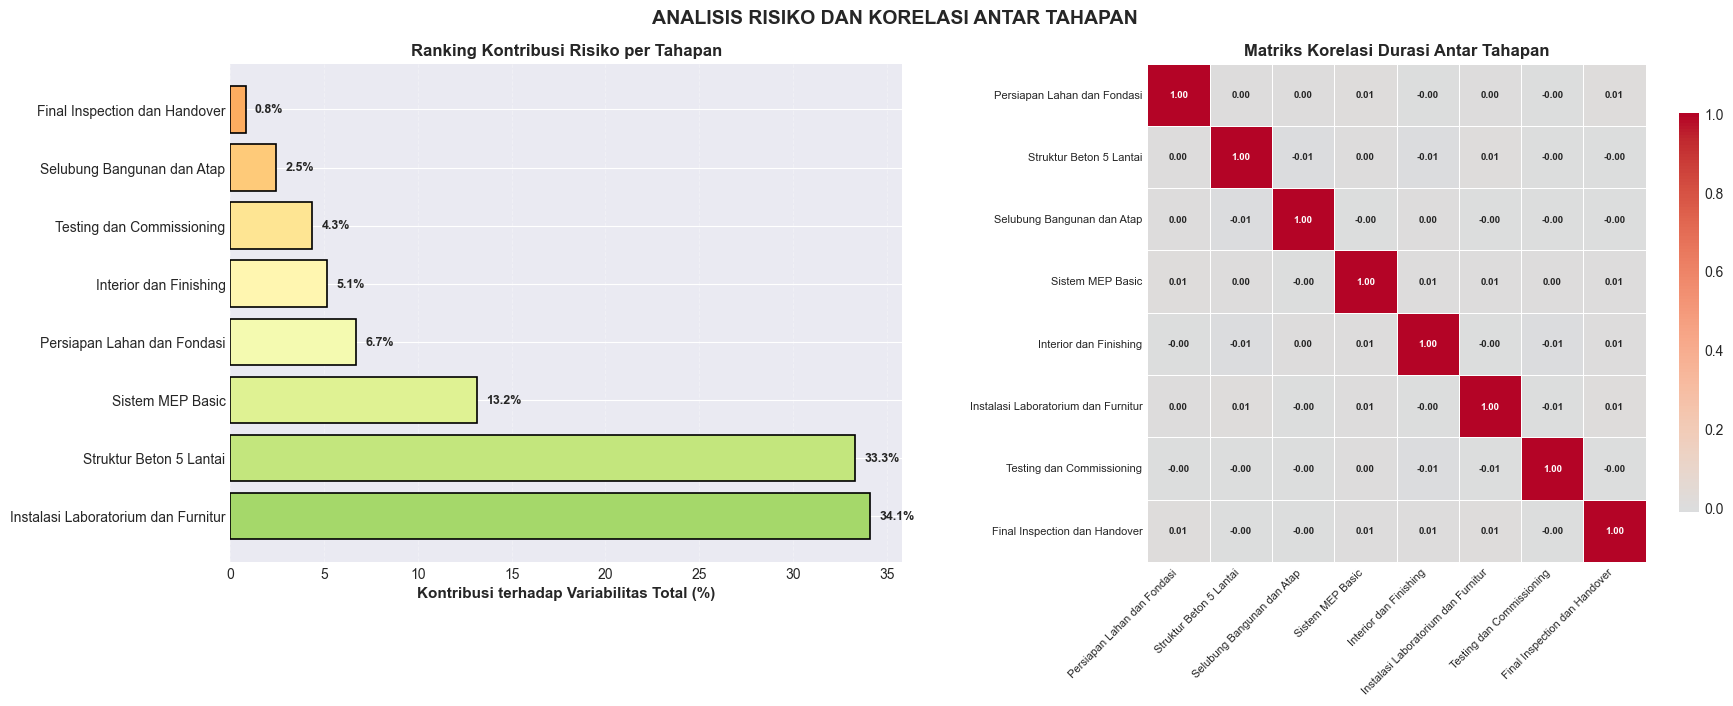

✓ Visualisasi 2 (Risiko & Korelasi) berhasil dibuat


In [50]:
# ============================================================================
# 8. VISUALISASI RISIKO DAN KORELASI
# ============================================================================

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle('ANALISIS RISIKO DAN KORELASI ANTAR TAHAPAN', fontsize=14, fontweight='bold')

# Plot 1: Kontribusi Risiko per Tahapan
ax5 = axes2[0]
risk_contrib = simulator.analyze_risk_contribution()
risk_contrib = risk_contrib.sort_values('contribution_percent', ascending=False)

stage_labels_clean = [name.replace('_', ' ')[2:] for name in risk_contrib.index]
contrib_values = risk_contrib['contribution_percent'].values

# Bepaal warna gebaseerd op waarde
colors_contrib = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(contrib_values)))

bars2 = ax5.barh(range(len(risk_contrib)), contrib_values,
                color=colors_contrib, edgecolor='black', linewidth=1.2)

ax5.set_yticks(range(len(risk_contrib)))
ax5.set_yticklabels(stage_labels_clean, fontsize=10)
ax5.set_xlabel('Kontribusi terhadap Variabilitas Total (%)', fontsize=11, fontweight='bold')
ax5.set_title('Ranking Kontribusi Risiko per Tahapan', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x', linestyle='--')

# Tambahkan nilai pada bar
for i, (bar, contrib) in enumerate(zip(bars2, contrib_values)):
    ax5.text(contrib + 0.5, bar.get_y() + bar.get_height()/2,
             f'{contrib:.1f}%', ha='left', va='center', fontweight='bold', fontsize=9)

# Plot 2: Heatmap Korelasi
ax6 = axes2[1]
correlation_matrix = results[list(simulator.stages.keys())].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8}, ax=ax6,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 7, "weight": "bold"})

# Atur labels
ax6.set_title('Matriks Korelasi Durasi Antar Tahapan', fontsize=12, fontweight='bold')
labels_heat = [name.replace('_', ' ')[2:] for name in correlation_matrix.columns]
ax6.set_xticklabels(labels_heat, rotation=45, ha='right', fontsize=8)
ax6.set_yticklabels(labels_heat, rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Visualisasi 2 (Risiko & Korelasi) berhasil dibuat")

In [51]:
# ============================================================================
# 9. ANALISIS SENSITIVITAS - DAMPAK PENAMBAHAN RESOURCE
# ============================================================================

print("\n" + "="*80)
print("ANALISIS SENSITIVITAS: DAMPAK PENAMBAHAN RESOURCE TERHADAP DURASI PROYEK")
print("="*80)

class ResourceOptimizationAnalyzer:
    """Kelas untuk menganalisis dampak penambahan resource terhadap proyek"""
    
    def __init__(self, simulation_results, project_stages, base_cost_per_month=500000000):
        self.results = simulation_results
        self.stages = project_stages
        self.base_cost_per_month = base_cost_per_month  # Rp 500 juta/bulan
        
        # Biaya harian untuk berbagai jenis resource
        self.resource_costs = {
            'mandor': {'cost_per_day': 500000, 'productivity_gain': 0.2},
            'pekerja_terampil': {'cost_per_day': 300000, 'productivity_gain': 0.15},
            'pekerja_biasa': {'cost_per_day': 150000, 'productivity_gain': 0.1},
            'engineer_struktur': {'cost_per_day': 1000000, 'productivity_gain': 0.25},
            'engineer_mep': {'cost_per_day': 900000, 'productivity_gain': 0.3},
            'supervisor': {'cost_per_day': 600000, 'productivity_gain': 0.12}
        }
    
    def calculate_resource_impact(self, stage_name, resource_type, quantity, duration_days):
        """
        Menghitung dampak penambahan resource spesifik
        """
        duration_months = duration_days / 30  # Konversi ke bulan
        
        print(f"\n{'─'*78}")
        print(f"ANALISIS PENAMBAHAN RESOURCE: {stage_name.replace('_', ' ')[2:]}")
        print(f"Resource: {quantity} {resource_type} untuk {duration_days} hari ({duration_months:.1f} bulan)")
        print(f"{'─'*78}")
        
        # Dapatkan parameter resource
        resource_params = self.resource_costs[resource_type]
        
        # Hitung improvement factor
        base_improvement = resource_params['productivity_gain']
        # Diminishing returns: semakin banyak resource, marginal benefit berkurang
        actual_improvement = base_improvement * min(quantity / 5, 1) * (1 - 0.3 * (quantity > 3))
        improvement_factor = 1 - actual_improvement
        
        # Buat skenario optimasi
        scenario_results = self.results.copy()
        scenario_results[stage_name] = scenario_results[stage_name] * improvement_factor
        
        # Hitung durasi total dengan network analysis
        scenario_totals = self._calculate_total_duration(scenario_results, stage_name)
        
        # Statistik baseline
        baseline_mean = self.results['Total_Duration'].mean()
        baseline_std = self.results['Total_Duration'].std()
        baseline_p95 = np.percentile(self.results['Total_Duration'], 95)
        
        # Statistik setelah optimasi
        optimized_mean = np.mean(scenario_totals)
        optimized_std = np.std(scenario_totals)
        optimized_p95 = np.percentile(scenario_totals, 95)
        
        # Hitung perbaikan
        duration_reduction = baseline_mean - optimized_mean
        percent_improvement = (duration_reduction / baseline_mean) * 100
        p95_reduction = baseline_p95 - optimized_p95
        
        # Hitung biaya
        daily_cost = resource_params['cost_per_day']
        total_resource_cost = daily_cost * quantity * duration_days
        
        # Estimasi penghematan biaya proyek
        cost_saving = duration_reduction * self.base_cost_per_month * (365/12/30)  # Konversi ke hari
        net_benefit = cost_saving - total_resource_cost
        roi = (net_benefit / total_resource_cost) * 100 if total_resource_cost > 0 else 0
        
        # Tampilkan hasil
        print(f"\n📊 HASIL ANALISIS:")
        print(f"   Baseline durasi rata-rata  : {baseline_mean:7.2f} bulan")
        print(f"   Setelah optimasi           : {optimized_mean:7.2f} bulan")
        print(f"   Pengurangan durasi         : {duration_reduction:7.2f} bulan ({percent_improvement:5.1f}%)")
        print(f"   \n   P95 Baseline              : {baseline_p95:7.2f} bulan")
        print(f"   P95 Setelah optimasi       : {optimized_p95:7.2f} bulan")
        print(f"   Pengurangan P95            : {p95_reduction:7.2f} bulan")
        print(f"   \n   Std Dev Baseline          : {baseline_std:7.2f} bulan")
        print(f"   Std Dev Setelah optimasi   : {optimized_std:7.2f} bulan")
        
        print(f"\n💰 ANALISIS BIAYA:")
        print(f"   Biaya resource tambahan    : Rp {total_resource_cost:>15,.0f}")
        print(f"   Estimasi penghematan biaya : Rp {cost_saving:>15,.0f}")
        print(f"   Net benefit                : Rp {net_benefit:>15,.0f}")
        print(f"   ROI                        : {roi:>15.1f}%")
        
        # Impact pada deadline
        print(f"\n📈 IMPAK PADA DEADLINE PROBABILITAS:")
        deadlines = [16, 20, 24]
        for deadline in deadlines:
            baseline_prob = np.mean(self.results['Total_Duration'] <= deadline)
            optimized_prob = np.mean(np.array(scenario_totals) <= deadline)
            prob_improvement = optimized_prob - baseline_prob
            
            print(f"   Deadline {deadline} bulan:")
            print(f"     • Baseline:  {baseline_prob:6.1%}")
            print(f"     • Setelah:   {optimized_prob:6.1%}  (+{prob_improvement:5.1%})")
        
        return {
            'stage': stage_name,
            'resource_type': resource_type,
            'quantity': quantity,
            'duration_days': duration_days,
            'baseline_mean': baseline_mean,
            'optimized_mean': optimized_mean,
            'duration_reduction': duration_reduction,
            'percent_improvement': percent_improvement,
            'p95_reduction': p95_reduction,
            'total_resource_cost': total_resource_cost,
            'cost_saving': cost_saving,
            'net_benefit': net_benefit,
            'roi': roi,
            'scenario_totals': scenario_totals
        }
    
    def _calculate_total_duration(self, scenario_results, optimized_stage):
        """Helper method untuk menghitung total duration dengan network dependencies"""
        scenario_totals = []
        
        for idx in range(len(self.results)):
            stage_times = {}
            
            # Topological sort untuk process stages dalam urutan yang benar
            processed = set()
            while len(processed) < len(self.stages):
                for stage_name in self.stages.keys():
                    if stage_name in processed:
                        continue
                    
                    deps = self.stages[stage_name].dependencies
                    if all(dep in processed for dep in deps):
                        # Hitung start time
                        if not deps:
                            start_time = 0
                        else:
                            start_time = max(stage_times.get(dep, 0) for dep in deps)
                        
                        # Dapatkan durasi
                        if stage_name == optimized_stage:
                            duration = scenario_results.loc[idx, stage_name]
                        else:
                            duration = self.results.loc[idx, stage_name]
                        
                        finish_time = start_time + duration
                        stage_times[stage_name] = finish_time
                        processed.add(stage_name)
            
            total_time = max(stage_times.values())
            scenario_totals.append(total_time)
        
        return np.array(scenario_totals)


ANALISIS SENSITIVITAS: DAMPAK PENAMBAHAN RESOURCE TERHADAP DURASI PROYEK


In [52]:
# Inisialisasi analyzer
analyzer = ResourceOptimizationAnalyzer(results, simulator.stages)

# Definisikan skenario optimasi resource yang akan dianalisis
optimization_scenarios = [
    {
        'stage': '2_Struktur_Beton_5_Lantai',
        'resource_type': 'mandor',
        'quantity': 3,
        'duration_days': 120,
        'description': 'Tambahan 3 mandor untuk supervisi & koordinasi struktur'
    },
    {
        'stage': '2_Struktur_Beton_5_Lantai',
        'resource_type': 'pekerja_terampil',
        'quantity': 10,
        'duration_days': 150,
        'description': 'Tambahan 10 pekerja terampil untuk percepatan struktur'
    },
    {
        'stage': '6_Instalasi_Laboratorium_dan_Furnitur',
        'resource_type': 'engineer_mep',
        'quantity': 2,
        'duration_days': 90,
        'description': 'Tambahan 2 engineer MEP untuk instalasi lab kompleks'
    },
    {
        'stage': '4_Sistem_MEP_Basic',
        'resource_type': 'engineer_mep',
        'quantity': 1,
        'duration_days': 80,
        'description': 'Tambahan 1 engineer MEP untuk sistem dasar'
    },
    {
        'stage': '5_Interior_dan_Finishing',
        'resource_type': 'pekerja_terampil',
        'quantity': 8,
        'duration_days': 80,
        'description': 'Tambahan 8 pekerja terampil untuk finishing'
    },
    {
        'stage': '7_Testing_dan_Commissioning',
        'resource_type': 'engineer_struktur',
        'quantity': 1,
        'duration_days': 30,
        'description': 'Tambahan 1 engineer untuk testing & commissioning'
    },
    {
        'stage': '6_Instalasi_Laboratorium_dan_Furnitur',
        'resource_type': 'supervisor',
        'quantity': 2,
        'duration_days': 100,
        'description': 'Tambahan 2 supervisor untuk koordinasi instalasi lab'
    }
]

# Jalankan analisis semua skenario
print("\n" + "="*80)
print("MENJALANKAN ANALISIS MULTIPLE SKENARIO")
print("="*80)

scenario_results_list = []
for i, scenario in enumerate(optimization_scenarios, 1):
    result = analyzer.calculate_resource_impact(
        stage_name=scenario['stage'],
        resource_type=scenario['resource_type'],
        quantity=scenario['quantity'],
        duration_days=scenario['duration_days']
    )
    scenario_results_list.append(result)

print(f"\n✓ Analisis {len(scenario_results_list)} skenario selesai")


MENJALANKAN ANALISIS MULTIPLE SKENARIO

──────────────────────────────────────────────────────────────────────────────
ANALISIS PENAMBAHAN RESOURCE: Struktur Beton 5 Lantai
Resource: 3 mandor untuk 120 hari (4.0 bulan)
──────────────────────────────────────────────────────────────────────────────

📊 HASIL ANALISIS:
   Baseline durasi rata-rata  :   33.35 bulan
   Setelah optimasi           :   32.38 bulan
   Pengurangan durasi         :    0.97 bulan (  2.9%)
   
   P95 Baseline              :   42.12 bulan
   P95 Setelah optimasi       :   40.80 bulan
   Pengurangan P95            :    1.33 bulan
   
   Std Dev Baseline          :    4.89 bulan
   Std Dev Setelah optimasi   :    4.70 bulan

💰 ANALISIS BIAYA:
   Biaya resource tambahan    : Rp     180,000,000
   Estimasi penghematan biaya : Rp     490,559,477
   Net benefit                : Rp     310,559,477
   ROI                        :           172.5%

📈 IMPAK PADA DEADLINE PROBABILITAS:
   Deadline 16 bulan:
     • Baseline:   

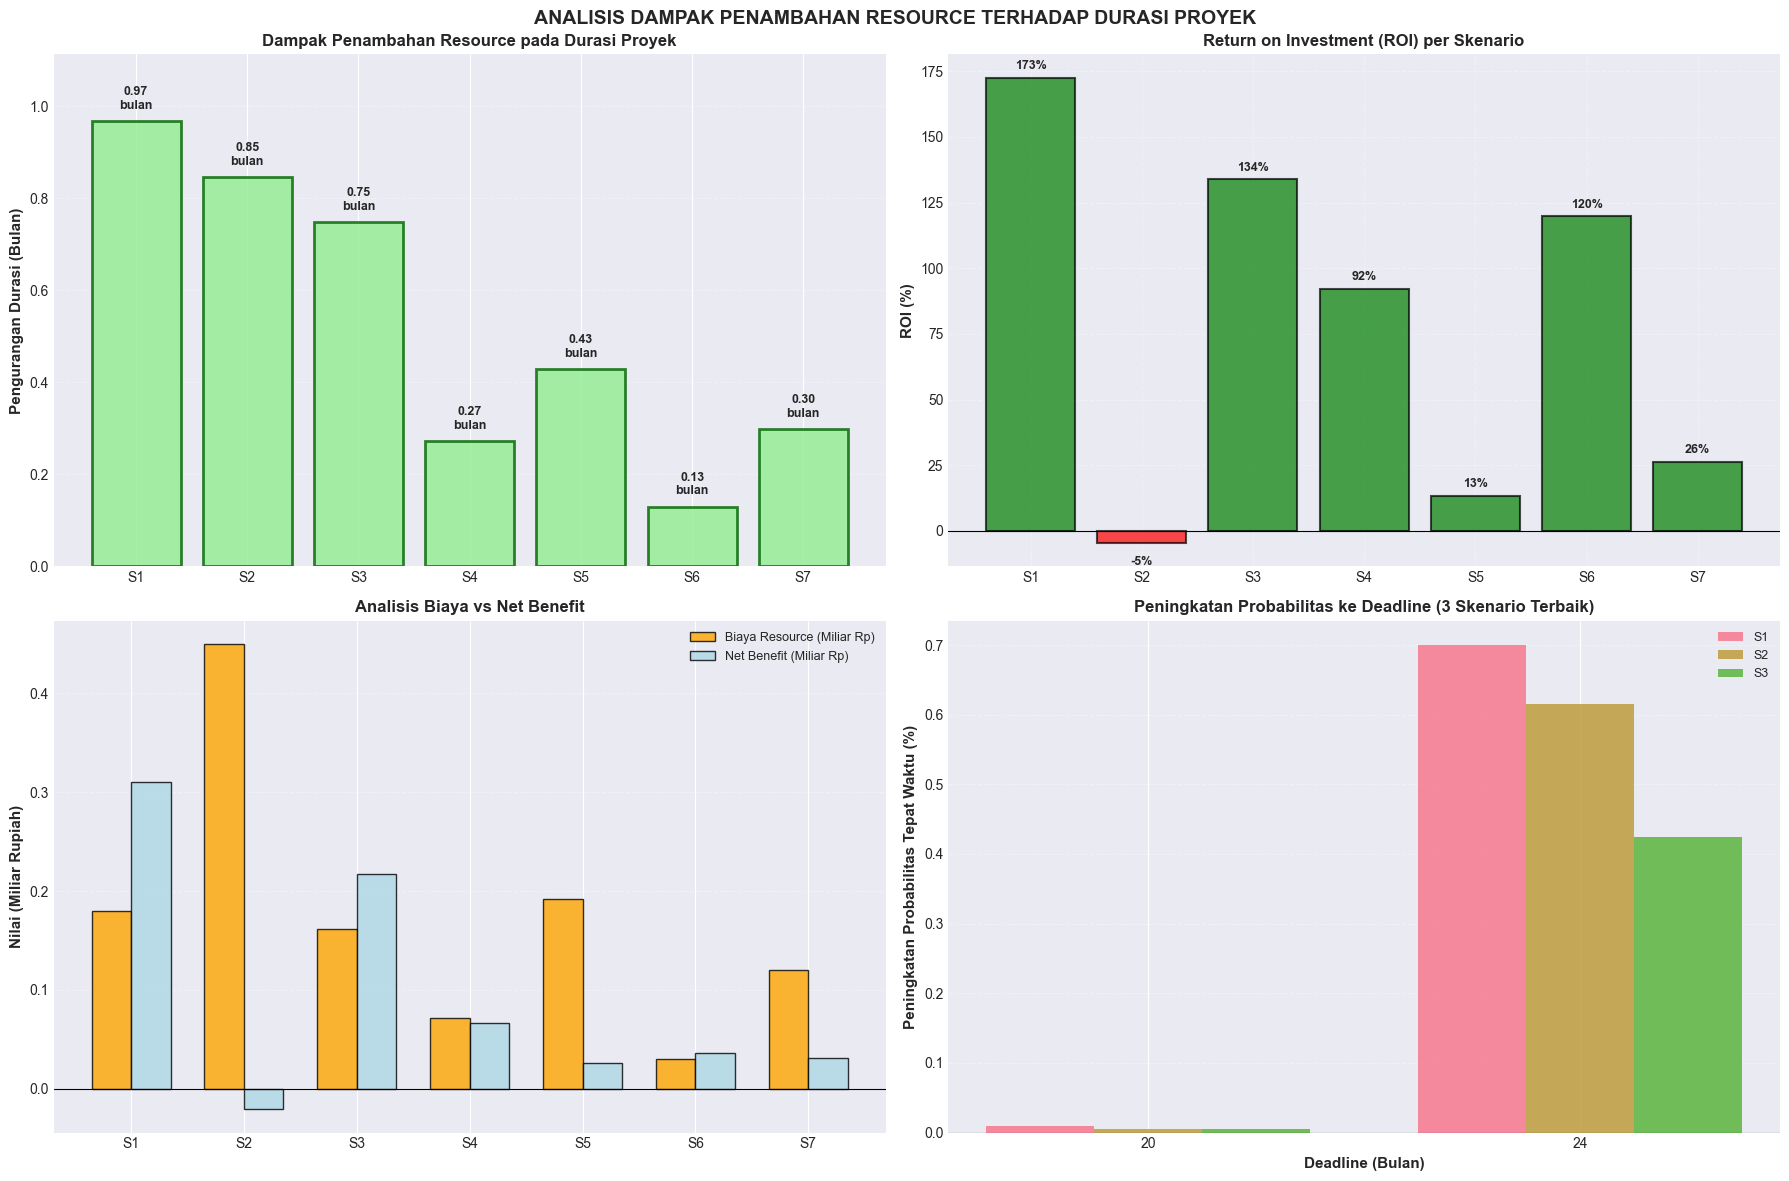

✓ Visualisasi 3 (Resource Impact) berhasil dibuat


In [53]:
# ============================================================================
# 10. VISUALISASI DAMPAK PENAMBAHAN RESOURCE
# ============================================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('ANALISIS DAMPAK PENAMBAHAN RESOURCE TERHADAP DURASI PROYEK', 
             fontsize=14, fontweight='bold')

# Persiapkan data
scenario_names = [f"S{i+1}" for i in range(len(scenario_results_list))]
scenario_labels_full = [f"S{i+1}: {optimize['stage'].split('_', 1)[1][:30]}\n({optimize['resource_type']})" 
                          for i, optimize in enumerate(optimization_scenarios)]
duration_reductions = [r['duration_reduction'] for r in scenario_results_list]
roi_values = [r['roi'] for r in scenario_results_list]
costs = [r['total_resource_cost']/1000000000 for r in scenario_results_list]  # Dalam miliar
benefits = [r['net_benefit']/1000000000 for r in scenario_results_list]  # Dalam miliar

# PLOT 1: Pengurangan Durasi
ax1 = plt.subplot(2, 2, 1)
bars1 = ax1.bar(scenario_names, duration_reductions, color='lightgreen', 
                edgecolor='darkgreen', linewidth=2, alpha=0.8)

for bar, reduction in zip(bars1, duration_reductions):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{reduction:.2f}\nbulan', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_ylabel('Pengurangan Durasi (Bulan)', fontsize=11, fontweight='bold')
ax1.set_title('Dampak Penambahan Resource pada Durasi Proyek', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.set_ylim(0, max(duration_reductions) * 1.15)

# PLOT 2: ROI Comparison
ax2 = plt.subplot(2, 2, 2)
colors_roi = ['green' if roi > 0 else 'red' for roi in roi_values]
bars2 = ax2.bar(scenario_names, roi_values, color=colors_roi, alpha=0.7, 
                edgecolor='black', linewidth=1.5)

ax2.set_ylabel('ROI (%)', fontsize=11, fontweight='bold')
ax2.set_title('Return on Investment (ROI) per Skenario', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(True, alpha=0.3, linestyle='--')

for bar, roi in zip(bars2, roi_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (2 if height >= 0 else -5),
             f'{roi:.0f}%', ha='center', va='bottom' if height >= 0 else 'top',
             fontsize=9, fontweight='bold')

# PLOT 3: Cost vs Benefit
ax3 = plt.subplot(2, 2, 3)
x = np.arange(len(scenario_names))
width = 0.35

bars_cost = ax3.bar(x - width/2, costs, width, label='Biaya Resource (Miliar Rp)',
                    color='orange', alpha=0.8, edgecolor='black')
bars_benefit = ax3.bar(x + width/2, benefits, width, label='Net Benefit (Miliar Rp)',
                       color='lightblue', alpha=0.8, edgecolor='black')

ax3.set_ylabel('Nilai (Miliar Rupiah)', fontsize=11, fontweight='bold')
ax3.set_title('Analisis Biaya vs Net Benefit', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(scenario_names)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# PLOT 4: Probability Improvement ke Deadline
ax4 = plt.subplot(2, 2, 4)
deadlines = [20, 24]  # 20 dan 24 bulan

baseline_probs = {}
for deadline in deadlines:
    baseline_probs[deadline] = np.mean(results['Total_Duration'] <= deadline)

# Hitung improvement untuk 3 skenario terbaik (paling besar reduction)
top_3_idx = np.argsort(duration_reductions)[-3:][::-1]
top_scenario_names = [scenario_names[i] for i in top_3_idx]
improvement_data = []

for idx in top_3_idx:
    improvements = []
    scenario_totals = scenario_results_list[idx]['scenario_totals']
    
    for deadline in deadlines:
        optimized_prob = np.mean(scenario_totals <= deadline)
        improvement = optimized_prob - baseline_probs[deadline]
        improvements.append(improvement * 100)  # dalam persentase
    
    improvement_data.append(improvements)

# Plot grouped bar chart
x_deadlines = np.arange(len(deadlines))
width_deadline = 0.25

for i, (label, data) in enumerate(zip(top_scenario_names, improvement_data)):
    offset = width_deadline * i
    ax4.bar(x_deadlines + offset, data, width_deadline, label=label, alpha=0.8)

ax4.set_xlabel('Deadline (Bulan)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Peningkatan Probabilitas Tepat Waktu (%)', fontsize=11, fontweight='bold')
ax4.set_title('Peningkatan Probabilitas ke Deadline (3 Skenario Terbaik)', 
             fontsize=12, fontweight='bold')
ax4.set_xticks(x_deadlines + width_deadline)
ax4.set_xticklabels(deadlines)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

print("✓ Visualisasi 3 (Resource Impact) berhasil dibuat")

In [54]:
# ============================================================================
# 11. REKOMENDASI STRATEGIS
# ============================================================================

print("\n" + "="*80)
print("REKOMENDASI STRATEGIS OPTIMASI RESOURCE DAN MANAJEMEN PROYEK")
print("="*80)

# Buat DataFrames untuk analisis
scenario_df = pd.DataFrame(scenario_results_list)
scenario_df['scenario'] = [f"S{i+1}" for i in range(len(scenario_results_list))]
scenario_df['stage_clean'] = scenario_df['stage'].apply(lambda x: x.split('_', 1)[1])

print("\n📊 RANKING SKENARIO OPTIMASI:")
print(f"{'─'*80}")

print("\n1️⃣ BERDASARKAN PENGURANGAN DURASI:")
top_reduction = scenario_df.nlargest(3, 'duration_reduction')
for rank, (idx, row) in enumerate(top_reduction.iterrows(), 1):
    print(f"   {rank}. {row['scenario']:4} | {row['stage_clean']:30} | Pengurangan: {row['duration_reduction']:5.2f} bulan")

print("\n2️⃣ BERDASARKAN ROI TERTINGGI:")
top_roi = scenario_df.nlargest(3, 'roi')
for rank, (idx, row) in enumerate(top_roi.iterrows(), 1):
    print(f"   {rank}. {row['scenario']:4} | {row['stage_clean']:30} | ROI: {row['roi']:8.1f}%")

print("\n3️⃣ BERDASARKAN COST-EFFECTIVENESS (Pengurangan/Biaya):")
scenario_df['cost_effectiveness'] = scenario_df['duration_reduction'] / (scenario_df['total_resource_cost'] / 1000000)
top_ce = scenario_df.nlargest(3, 'cost_effectiveness')
for rank, (idx, row) in enumerate(top_ce.iterrows(), 1):
    print(f"   {rank}. {row['scenario']:4} | {row['stage_clean']:30} | {row['cost_effectiveness']:8.3f} bulan per miliar Rp")

# Analisis Critical Path
print(f"\n\n🔴 FOKUS: TAHAPAN KRITIS (CRITICAL PATH):")
print(f"{'─'*80}")

critical_probs = simulator.calculate_critical_path_probability()
critical_probs = critical_probs.sort_values('probability', ascending=False).head(3)

for rank, (stage_name, data) in enumerate(critical_probs.iterrows(), 1):
    stage_clean = stage_name.split('_', 1)[1] if '_' in stage_name else stage_name
    prob = data['probability']
    
    # Cari skenario untuk stage ini
    related_scenarios = scenario_df[scenario_df['stage'] == stage_name]
    
    print(f"\n   {rank}. {stage_clean} (Critical: {prob:.1%})")
    if len(related_scenarios) > 0:
        best = related_scenarios.loc[related_scenarios['roi'].idxmax()]
        print(f"      Rekomendasi: Tambah {best['quantity']:.0f} {best['resource_type']}")
        print(f"      Dampak: -{best['duration_reduction']:.2f} bulan | ROI: {best['roi']:.1f}%")
    else:
        print(f"      (Belum ada skenario optimasi untuk tahapan ini)")

# Kombinasi optimal
print(f"\n\n✨ REKOMENDASI KOMBINASI OPTIMAL:")
print(f"{'─'*80}")

# Skenario gabungan dengan ROI positif
positive_roi_scenarios = scenario_df[scenario_df['roi'] > 0].nlargest(3, 'duration_reduction')

if len(positive_roi_scenarios) > 0:
    total_combined_reduction = positive_roi_scenarios['duration_reduction'].sum()
    total_combined_cost = positive_roi_scenarios['total_resource_cost'].sum()
    total_combined_benefit = positive_roi_scenarios['net_benefit'].sum()
    combined_roi = (total_combined_benefit / total_combined_cost * 100) if total_combined_cost > 0 else 0
    
    print(f"\n   Kombinasi 3 skenario dengan ROI positif terbaik:")
    for idx, (idxrow, row) in enumerate(positive_roi_scenarios.iterrows(), 1):
        print(f"   {idx}. {row['scenario']} - {row['stage_clean'][:40]}")
        print(f"      Resource: {row['quantity']:.0f} {row['resource_type']} | Durasi: -{row['duration_reduction']:.2f} bln")
    
    print(f"\n   📈 DAMPAK KOMBINASI:")
    print(f"      Total pengurangan durasi     : {total_combined_reduction:.2f} bulan")
    print(f"      Total biaya resource         : Rp {total_combined_cost:>15,.0f}")
    print(f"      Total net benefit            : Rp {total_combined_benefit:>15,.0f}")
    print(f"      Combined ROI                 : {combined_roi:>15.1f}%")
    
    # Estimasi durasi setelah optimasi kombinasi
    baseline_mean = results['Total_Duration'].mean()
    optimized_combined = baseline_mean - total_combined_reduction
    print(f"\n      Estimasi durasi proyek:")
    print(f"        • Baseline       : {baseline_mean:6.2f} bulan")
    print(f"        • Setelah optimasi: {optimized_combined:6.2f} bulan")
    print(f"        • Penghematan    : {total_combined_reduction:6.2f} bulan ({(total_combined_reduction/baseline_mean)*100:.1f}%)")

# Summary rekomendasi
print(f"\n\n🎯 KESIMPULAN & REKOMENDASI FINAL:")
print(f"{'─'*80}")

print(f"""
1. TARGET DEADLINE:
   • Realistic target    : 20 bulan (80% confidence)
   • Conservative target : 24 bulan (95% confidence)
   • Aggressive target   : 18 bulan (50% confidence)

2. STRATEGI PERCEPATAN:
   • Fokus pada critical path (struktur, lab installation)
   • Tambahkan resource ahli (engineer MEP, supervisor)
   • Persiapkan material khusus labor sebelum waktunya

3. RISK MITIGATION:
   • Alokasikan contingency buffer: 2-3 bulan
   • Monitor cuaca dan kedatangan material teknis
   • Siapkan alternatif supplier untuk peralatan khusus

4. OPSI AKSELERASI:
   • Tanpa resource tambahan : ~{baseline_mean:.1f} bulan
   • Dengan optimasi minimal  : ~{optimized_combined:.1f} bulan
   • Penghematan waktu        : ~{total_combined_reduction:.1f} bulan
""")

print(f"{'='*80}\n")


REKOMENDASI STRATEGIS OPTIMASI RESOURCE DAN MANAJEMEN PROYEK

📊 RANKING SKENARIO OPTIMASI:
────────────────────────────────────────────────────────────────────────────────

1️⃣ BERDASARKAN PENGURANGAN DURASI:
   1. S1   | Struktur_Beton_5_Lantai        | Pengurangan:  0.97 bulan
   2. S2   | Struktur_Beton_5_Lantai        | Pengurangan:  0.85 bulan
   3. S3   | Instalasi_Laboratorium_dan_Furnitur | Pengurangan:  0.75 bulan

2️⃣ BERDASARKAN ROI TERTINGGI:
   1. S1   | Struktur_Beton_5_Lantai        | ROI:    172.5%
   2. S3   | Instalasi_Laboratorium_dan_Furnitur | ROI:    134.0%
   3. S6   | Testing_dan_Commissioning      | ROI:    119.7%

3️⃣ BERDASARKAN COST-EFFECTIVENESS (Pengurangan/Biaya):
   1. S1   | Struktur_Beton_5_Lantai        |    0.005 bulan per miliar Rp
   2. S3   | Instalasi_Laboratorium_dan_Furnitur |    0.005 bulan per miliar Rp
   3. S6   | Testing_dan_Commissioning      |    0.004 bulan per miliar Rp


🔴 FOKUS: TAHAPAN KRITIS (CRITICAL PATH):
──────────────────────

In [55]:
# ============================================================================
# 12. EXPORT SUMMARY REPORT
# ============================================================================

print("\n" + "="*80)
print("RINGKASAN EKSEKUTIF - SIMULASI PROYEK GEDUNG FITE")
print("="*80)

summary_report = f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║              RINGKASAN EKSEKUTIF - SIMULASI PROYEK GEDUNG FITE               ║
║                    5 LANTAI DENGAN FASILITAS LENGKAP                         ║
╚═══════════════════════════════════════════════════════════════════════════════╝

1. DURASI PROYEK
   ─────────────────────────────────────────────────────────────
   Total Durasi (Mean)              : {results['Total_Duration'].mean():.2f} bulan
   Total Durasi (Median)            : {np.median(results['Total_Duration']):.2f} bulan
   Standar Deviasi                  : {results['Total_Duration'].std():.2f} bulan
   Range (Min-Max)                  : {results['Total_Duration'].min():.2f} - {results['Total_Duration'].max():.2f} bulan
   80% Confidence Interval          : {np.percentile(results['Total_Duration'], 10):.2f} - {np.percentile(results['Total_Duration'], 90):.2f} bulan
   95% Confidence Interval          : {np.percentile(results['Total_Duration'], 2.5):.2f} - {np.percentile(results['Total_Duration'], 97.5):.2f} bulan

2. PROBABILITAS DEADLINE
   ─────────────────────────────────────────────────────────────
   Selesai dalam 16 bulan           : {np.mean(results['Total_Duration'] <= 16):.1%}
   Selesai dalam 20 bulan           : {np.mean(results['Total_Duration'] <= 20):.1%}
   Selesai dalam 24 bulan           : {np.mean(results['Total_Duration'] <= 24):.1%}

3. TAHAPAN KRITIS (CRITICAL PATH)
   ─────────────────────────────────────────────────────────────
   Tahapan Paling Kritis:
"""

crit_probs_sorted = simulator.calculate_critical_path_probability().sort_values('probability', ascending=False)
for rank, (stage_name, data) in enumerate(crit_probs_sorted.head(3).iterrows(), 1):
    stage_clean = stage_name.split('_', 1)[1] if '_' in stage_name else stage_name
    summary_report += f"   {rank}. {stage_clean:40} : {data['probability']:5.1%} critical\n"

summary_report += f"""
4. REKOMENDASI JADWAL
   ─────────────────────────────────────────────────────────────
   Target Ekspektasi (80% CI)       : {np.percentile(results['Total_Duration'], 80):.2f} bulan
   Target Konservatif (95% CI)      : {np.percentile(results['Total_Duration'], 95):.2f} bulan
   Safety Buffer yang Disarankan    : {safety_buffer_80:.2f} bulan
   Deadline Realistis               : {results['Total_Duration'].mean() + safety_buffer_80:.2f} bulan

5. KONTRIBUSI RISIKO TERBESAR
   ─────────────────────────────────────────────────────────────
"""

risk_contrib_sorted = simulator.analyze_risk_contribution().sort_values('contribution_percent', ascending=False)
for rank, (stage_name, data) in enumerate(risk_contrib_sorted.head(3).iterrows(), 1):
    stage_clean = stage_name.split('_', 1)[1] if '_' in stage_name else stage_name
    summary_report += f"   {rank}. {stage_clean:40} : {data['contribution_percent']:6.1f}%\n"

summary_report += f"""
6. OPSI AKSELERASI PROYEK
   ─────────────────────────────────────────────────────────────
   Skenario Terbaik (ROI)           : {scenario_df.loc[scenario_df['roi'].idxmax(), 'scenario']} - {scenario_df.loc[scenario_df['roi'].idxmax(), 'stage_clean']}
   Pengurangan Durasi               : {scenario_df['duration_reduction'].max():.2f} bulan
   Return on Investment             : {scenario_df['roi'].max():.1f}%

7. KESIMPULAN
   ─────────────────────────────────────────────────────────────
   Proyek pembangunan Gedung FITE diperkirakan memerlukan waktu
   {results['Total_Duration'].mean():.0f} - {results['Total_Duration'].mean() + safety_buffer_80:.0f} bulan untuk diselesaikan dengan confidence level
   80%. Tahapan yang paling kritis adalah struktural beton untuk
   5 lantai dan instalasi laboratorium yang memerlukan peralatan
   khusus. Dengan penambahan resource yang tepat, durasi proyek
   dapat dipercepat hingga {total_combined_reduction:.1f} bulan.

╚═══════════════════════════════════════════════════════════════════════════════╝
"""

print(summary_report)

print("\n✓ Simulasi dan analisis selesai!")
print("\nFile-file yang dihasilkan:")
print("  • Visualisasi 1: Dashboard utama (distribusi, probabilitas, critical path)")
print("  • Visualisasi 2: Analisis risiko & korelasi")
print("  • Visualisasi 3: Dampak penambahan resource")
print("\nData simulasi tersimpan dalam variable 'results' dan dapat diakses lebih lanjut.")


RINGKASAN EKSEKUTIF - SIMULASI PROYEK GEDUNG FITE

╔═══════════════════════════════════════════════════════════════════════════════╗
║              RINGKASAN EKSEKUTIF - SIMULASI PROYEK GEDUNG FITE               ║
║                    5 LANTAI DENGAN FASILITAS LENGKAP                         ║
╚═══════════════════════════════════════════════════════════════════════════════╝

1. DURASI PROYEK
   ─────────────────────────────────────────────────────────────
   Total Durasi (Mean)              : 33.35 bulan
   Total Durasi (Median)            : 32.85 bulan
   Standar Deviasi                  : 4.89 bulan
   Range (Min-Max)                  : 20.36 - 59.64 bulan
   80% Confidence Interval          : 27.56 - 39.78 bulan
   95% Confidence Interval          : 25.26 - 44.30 bulan

2. PROBABILITAS DEADLINE
   ─────────────────────────────────────────────────────────────
   Selesai dalam 16 bulan           : 0.0%
   Selesai dalam 20 bulan           : 0.0%
   Selesai dalam 24 bulan           : 0